In [67]:
import pandas as pd
from scipy.io import loadmat
import os
import numpy as np
import matplotlib.pyplot as plt

In [68]:
raw_data_path = "../data/raw/"

In [69]:
data_filename = "B0018"
mat_data = loadmat(raw_data_path + data_filename + ".mat")
print(mat_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'B0018'])


In [70]:
print(mat_data["__header__"])
print(mat_data["__version__"])
print(mat_data["__globals__"])

b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Wed Oct 01 15:50:31 2008'
1.0
[]


In [71]:
cell_data = mat_data[data_filename]
total_cycles = len(cell_data[0,0]['cycle'][0])
print(total_cycles)

319


In [72]:
data = cell_data[0,0]['cycle'][0,0]
print(data.dtype)
print(f"Event: {data['type']}")
print(f"Ambient Temperature: {data['ambient_temperature']}")
print(data['data'][0,0].dtype)

[('type', 'O'), ('ambient_temperature', 'O'), ('time', 'O'), ('data', 'O')]
Event: ['charge']
Ambient Temperature: [[24]]
[('Voltage_measured', 'O'), ('Current_measured', 'O'), ('Temperature_measured', 'O'), ('Current_charge', 'O'), ('Voltage_charge', 'O'), ('Time', 'O')]


In [73]:
charge_fldr = "../data/processed/" + data_filename + "/charge/"
discharge_fldr = "../data/processed/" + data_filename + "/discharge/"

In [74]:
cycle_data = data['data'][0,0]
print(cycle_data['Time'])

[[0.000000e+00 2.484000e+00 5.109000e+00 ... 8.117328e+03 8.120078e+03
  8.122844e+03]]


In [75]:
import shutil

if os.path.exists(charge_fldr) == True:
    shutil.rmtree(charge_fldr)
    os.makedirs(charge_fldr)
    print(f"Created folder: {charge_fldr}")
else:
    os.makedirs(charge_fldr)
    print(f"Created folder: {charge_fldr}")


if os.path.exists(discharge_fldr) == True:
    shutil.rmtree(discharge_fldr)
    os.makedirs(discharge_fldr)
    print(f"Created folder: {discharge_fldr}")
else:
    os.makedirs(discharge_fldr)
    print(f"Created folder: {discharge_fldr}")

charge_count = 0
discharge_count = 0
impedance_count = 0
for i in range(total_cycles):
    raw_data = cell_data[0,0]['cycle'][0,i]
    event_type = raw_data['type'][0]
    ambient_temp = raw_data['ambient_temperature'][0,0]
    cycle_data = raw_data['data'][0,0]

    if event_type == "discharge":
        filename = discharge_fldr + f"dchgCycle_{discharge_count}.csv"
        df_cycle = pd.DataFrame()
        df_cycle["time"] = cycle_data['Time'][0]
        df_cycle["current"] = cycle_data['Current_measured'][0]
        df_cycle["voltage"] = cycle_data['Voltage_measured'][0]
        df_cycle["temperature"] = cycle_data['Temperature_measured'][0]
        df_cycle["capacity"] = np.ones((len(cycle_data['Time'][0]),1))*cycle_data['Capacity'][0]
        # print(df_cycle.head())
        df_cycle.to_csv(filename, index=False)
        discharge_count += 1

    if event_type == "charge":
        filename = charge_fldr + f"chgCycle_{charge_count}.csv"
        df_cycle = pd.DataFrame()
        df_cycle["time"] = cycle_data['Time'][0]
        df_cycle["current"] = cycle_data['Current_measured'][0]
        df_cycle["voltage"] = cycle_data['Voltage_measured'][0]
        df_cycle["temperature"] = cycle_data['Temperature_measured'][0]
        # df_cycle["capacity"] = cycle_data['Capacity'][0]
        # print(df_cycle.head())
        df_cycle.to_csv(filename, index=False)
        charge_count += 1
    
    if event_type == "impedance":
        impedance_count += 1
    

print(f"Discharge Files: {discharge_count}")
print(f"Charge Files: {charge_count}")
print(f"Impedance Files: {impedance_count}")

Created folder: ../data/processed/B0018/charge/
Created folder: ../data/processed/B0018/discharge/
Discharge Files: 132
Charge Files: 134
Impedance Files: 53


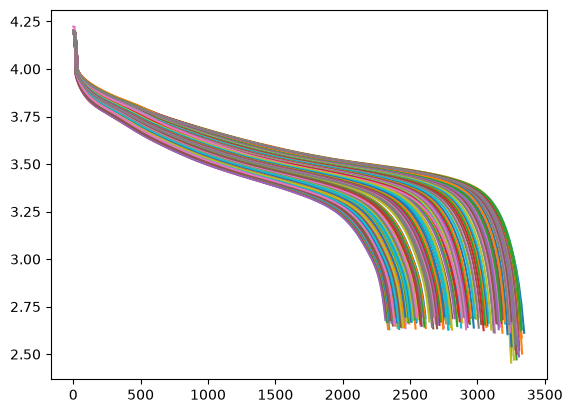

In [112]:
training_cells = ["B0005","B0006","B0007"]
processed_fldr = "../data/processed/"
for fldr in os.listdir(processed_fldr):
    if fldr == training_cells[0]:
        dchg_fldr = processed_fldr + fldr + "/discharge/"
        for file in os.listdir(dchg_fldr):
            filename = dchg_fldr + file
            df = pd.read_csv(filename)
            plt.plot(df["time"], df["voltage"])


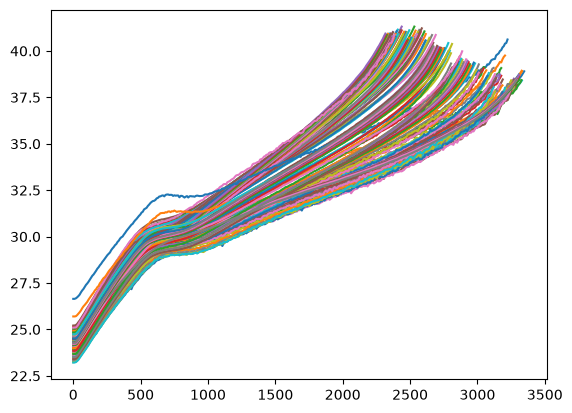

In [121]:
training_cells = ["B0005","B0006","B0007"]
processed_fldr = "../data/processed/"
for fldr in os.listdir(processed_fldr):
    if fldr == training_cells[0]:
        dchg_fldr = processed_fldr + fldr + "/discharge/"
        for file in os.listdir(dchg_fldr):
            filename = dchg_fldr + file
            df = pd.read_csv(filename)
            plt.plot(df["time"], df["temperature"])

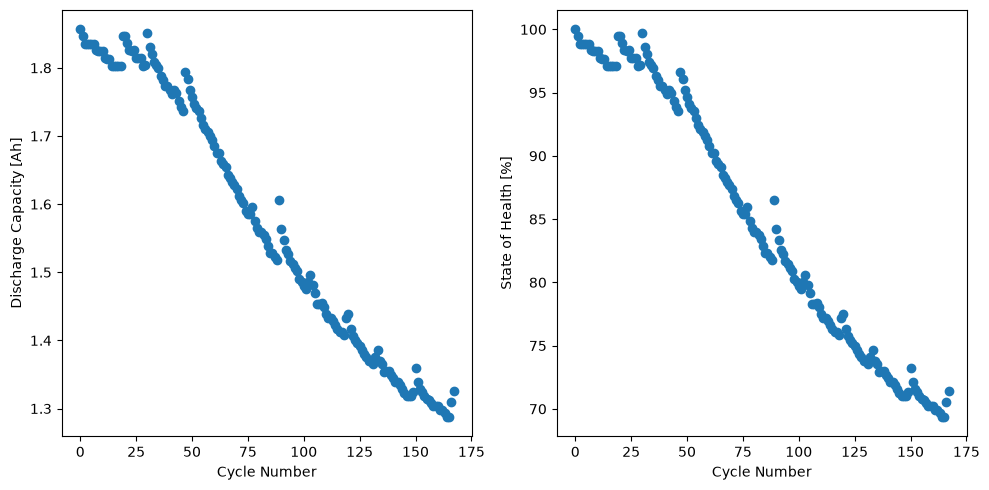

In [120]:
dchg_capacity = []
dchg_fileIndex = []
for fldr in os.listdir(processed_fldr):
    if fldr == training_cells[0]:
        dchg_fldr = processed_fldr + fldr + "/discharge/"
        for file in os.listdir(dchg_fldr):
            filename = dchg_fldr + file
            df = pd.read_csv(filename)
            fileindex = file.split(".")[0].split("_")[1]
            dchg_fileIndex.append(int(fileindex))
            dchg_capacity.append(df["capacity"][0])

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
ax[0].scatter(dchg_fileIndex, dchg_capacity)
ax[0].set_xlabel("Cycle Number")
ax[0].set_ylabel("Discharge Capacity [Ah]")

ax[1].scatter(dchg_fileIndex, (dchg_capacity/dchg_capacity[0])*100)
ax[1].set_xlabel("Cycle Number")
ax[1].set_ylabel("State of Health [%]")

plt.tight_layout()

In [113]:
for fldr in os.listdir(processed_fldr):
    dchg_fldr = processed_fldr + fldr + "/discharge/"
    for file in os.listdir(dchg_fldr):
        filename = dchg_fldr + file
        df = pd.read_csv(filename)
        index = df.index[df["current"] <= -0.01]
        df = df.iloc[0:index[-1]+1]
        df.to_csv(filename, index=False)

In [126]:
# soc calculation
for fldr in os.listdir(processed_fldr):
    dchg_fldr = processed_fldr + fldr + "/discharge/"
    for file in os.listdir(dchg_fldr):
        filename = dchg_fldr + file
        df = pd.read_csv(filename)
        df['soc'] = df['current']*df['time']/(df['capacity']*3600) + 1
        index = df.index[df["soc"] < 0]
        df.loc[index, 'soc'] = 0
        df.to_csv(filename, index=False)